# Exploratory Data Analysis

This notebook explores the processed service-zone-hour dataset created
during preprocessing. The main question is whether subway accessibility
is associated with taxi and ride-hailing demand, and whether this
relationship also appears in driver earning efficiency.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

PROJECT_ROOT = Path("/mnt/d/ADS_proj1")
ANALYSIS_PATH = PROJECT_ROOT / "data" / "processed" / "analysis_zone_hour"

spark = (
    SparkSession.builder
    .appName("MAST30034 Project 1 EDA")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.sql.shuffle.partitions", "24")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/03 04:01:49 WARN Utils: Your hostname, localhost, resolves to a loopback address: 127.0.0.1; using 10.255.255.254 instead (on interface lo)
26/09/03 04:01:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/liubi/.venvs/mast30034/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/03 04:01:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Data Coverage

First check the temporal coverage and spatial coverage of the processed
dataset. This confirms that the analysis uses the intended January to
June 2024 period and covers most NYC taxi zones.

In [2]:
analysis_df = spark.read.parquet(str(ANALYSIS_PATH))

coverage_summary = analysis_df.agg(
    F.min("pickup_hour").alias("start_time"),
    F.max("pickup_hour").alias("end_time"),
    F.count("*").alias("zone_hour_rows"),
    F.countDistinct("pickup_location_id").alias("pickup_zones"),
)
coverage_summary.toPandas()

/home/liubi/.venvs/mast30034/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/liubi/.venvs/mast30034/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,start_time,end_time,zone_hour_rows,pickup_zones
0,2024-01-01,2024-06-30 23:00:00,1663511,261


## Service Scale

Compare the overall scale of green taxi, yellow taxi, and HVFHV trips.
This is important because the three services have very different market
sizes, so later plots should usually separate service types.

In [3]:
service_summary = (
    analysis_df
    .groupBy("service_type")
    .agg(
        F.sum("trip_count").alias("total_trips"),
        F.count("*").alias("active_zone_hours"),
        F.countDistinct("pickup_location_id").alias("pickup_zones"),
    )
    .orderBy("service_type")
)

service_summary.toPandas()

/home/liubi/.venvs/mast30034/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,service_type,total_trips,active_zone_hours,pickup_zones
0,green,312598,85579,238
1,hvfhv,115816547,1097354,261
2,yellow,19347480,480578,258


## Subway Accessibility: First Summary

Aggregate demand and earning measures by service type and subway
accessibility level. This gives a broad first view before controlling
for borough, airports, and time of day.

In [4]:
access_summary = (
    analysis_df
    .groupBy("service_type", "subway_access_level")
    .agg(
        F.sum("trip_count").alias("total_trips"),
        F.count("*").alias("active_zone_hours"),
        F.countDistinct("pickup_location_id").alias("pickup_zones"),
        (
            F.sum(F.col("avg_earning_amount") * F.col("trip_count"))
            / F.sum("trip_count")
        ).alias("weighted_avg_earning_amount"),
        (
            F.sum(F.col("avg_earning_per_hour") * F.col("trip_count"))
            / F.sum("trip_count")
        ).alias("weighted_avg_earning_per_hour"),
        (
            F.sum(F.col("avg_trip_miles") * F.col("trip_count"))
            / F.sum("trip_count")
        ).alias("weighted_avg_trip_miles"),
    )
    .withColumn(
        "trips_per_active_zone_hour",
        F.col("total_trips") / F.col("active_zone_hours"),
    )
    .orderBy("service_type", "subway_access_level")
)

access_summary_pd = pd.DataFrame(
    [row.asDict() for row in access_summary.collect()]
)
access_summary_pd

,service_type,subway_access_level,total_trips,active_zone_hours,pickup_zones,weighted_avg_earning_amount,weighted_avg_earning_per_hour,weighted_avg_trip_miles,trips_per_active_zone_hour
0,green,high,288343,69718,119,22.659802,106.571272,2.740979,4.135847
1,green,low,7121,5246,71,32.838261,118.041073,4.649744,1.357415
2,green,medium,17134,10615,48,27.937393,106.781019,3.743353,1.614131
3,hvfhv,high,72811592,540855,124,17.681147,58.603681,4.196888,134.623128
4,hvfhv,low,17920155,337803,86,18.830218,61.156706,4.989902,53.049129
5,hvfhv,medium,25084800,218696,51,20.204303,59.286638,5.075238,114.701686
6,yellow,high,11554190,283056,124,23.949897,114.198318,2.504308,40.819449
7,yellow,low,1547627,77744,83,43.775331,128.720524,5.933810,19.906707
8,yellow,medium,6245663,119778,51,30.762184,119.758601,4.203998,52.143657


### Demand by Subway Accessibility

This initial demand plot is useful for seeing the broad pattern: high
subway-access zones tend to have stronger trip intensity, especially for
HVFHV. The airport-adjusted version later is better for the final report.

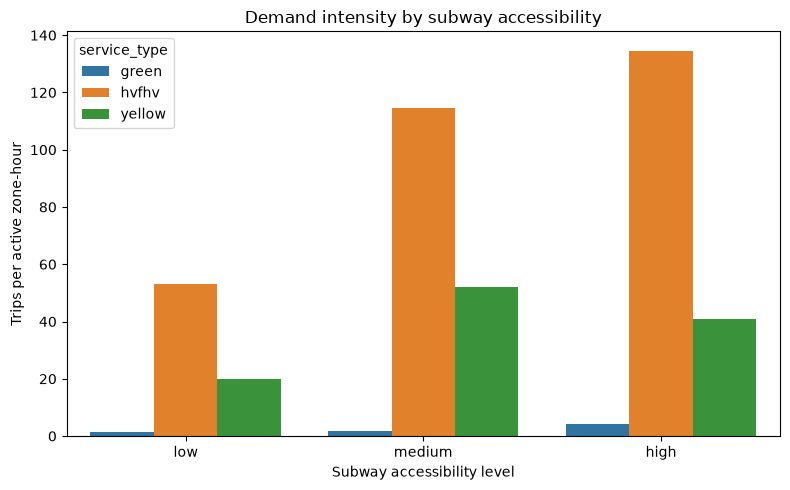

In [5]:
access_order = ["low", "medium", "high"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=access_summary_pd,
    x="subway_access_level",
    y="trips_per_active_zone_hour",
    hue="service_type",
    order=access_order,
)

plt.xlabel("Subway accessibility level")
plt.ylabel("Trips per active zone-hour")
plt.title("Demand intensity by subway accessibility")
plt.tight_layout()
plt.show()

### Earning Efficiency by Subway Accessibility

This plot is exploratory. It shows that higher subway accessibility does
not consistently imply higher earning efficiency, but cross-service
income comparisons should be interpreted carefully because yellow/green
and HVFHV use different earning fields.

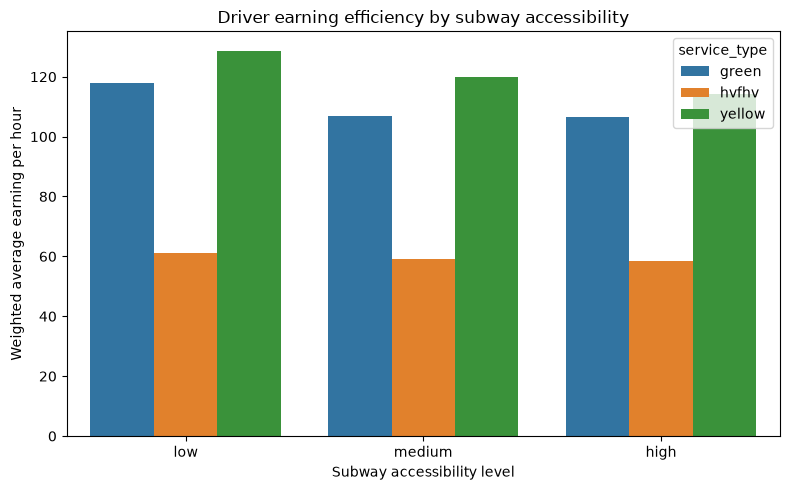

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=access_summary_pd,
    x="subway_access_level",
    y="weighted_avg_earning_per_hour",
    hue="service_type",
    order=access_order,
)

plt.xlabel("Subway accessibility level")
plt.ylabel("Weighted average earning per hour")
plt.title("Driver earning efficiency by subway accessibility")
plt.tight_layout()
plt.show()

## Borough-Controlled Accessibility Patterns

Borough is a major location factor, especially because high subway
accessibility is concentrated in dense areas such as Manhattan. The next
summary separates service type and borough to avoid mixing very different
markets together.

In [7]:
nyc_boroughs = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
access_order = ["low", "medium", "high"]

borough_access_summary = (
    analysis_df
    .filter(F.col("borough").isin(nyc_boroughs))
    .groupBy("service_type", "borough", "subway_access_level")
    .agg(
        F.sum("trip_count").alias("total_trips"),
        F.count("*").alias("active_zone_hours"),
        F.countDistinct("pickup_location_id").alias("pickup_zones"),
        (
            F.sum(F.col("avg_earning_per_hour") * F.col("trip_count"))
            / F.sum("trip_count")
        ).alias("weighted_avg_earning_per_hour"),
    )
    .withColumn(
        "trips_per_active_zone_hour",
        F.col("total_trips") / F.col("active_zone_hours"),
    )
    .orderBy("service_type", "borough", "subway_access_level")
)

borough_access_pd = pd.DataFrame(
    [row.asDict() for row in borough_access_summary.collect()]
)

borough_access_pd["borough"] = pd.Categorical(
    borough_access_pd["borough"],
    categories=nyc_boroughs,
    ordered=True,
)

borough_access_pd["subway_access_level"] = pd.Categorical(
    borough_access_pd["subway_access_level"],
    categories=access_order,
    ordered=True,
)

borough_access_pd = borough_access_pd.sort_values(
    ["service_type", "borough", "subway_access_level"]
)

borough_access_pd.head()

,service_type,borough,subway_access_level,total_trips,active_zone_hours,pickup_zones,weighted_avg_earning_per_hour,trips_per_active_zone_hour
1,green,Bronx,low,274,273,9,100.148824,1.003663
2,green,Bronx,medium,730,681,9,97.877370,1.071953
0,green,Bronx,high,2136,1821,21,102.731236,1.172982
4,green,Brooklyn,low,936,558,11,126.354228,1.677419
5,green,Brooklyn,medium,7479,3786,11,103.128179,1.975436


### Demand by Borough and Accessibility

This is one of the stronger EDA figures. It checks whether high-access
zones still have higher demand within each service and borough.

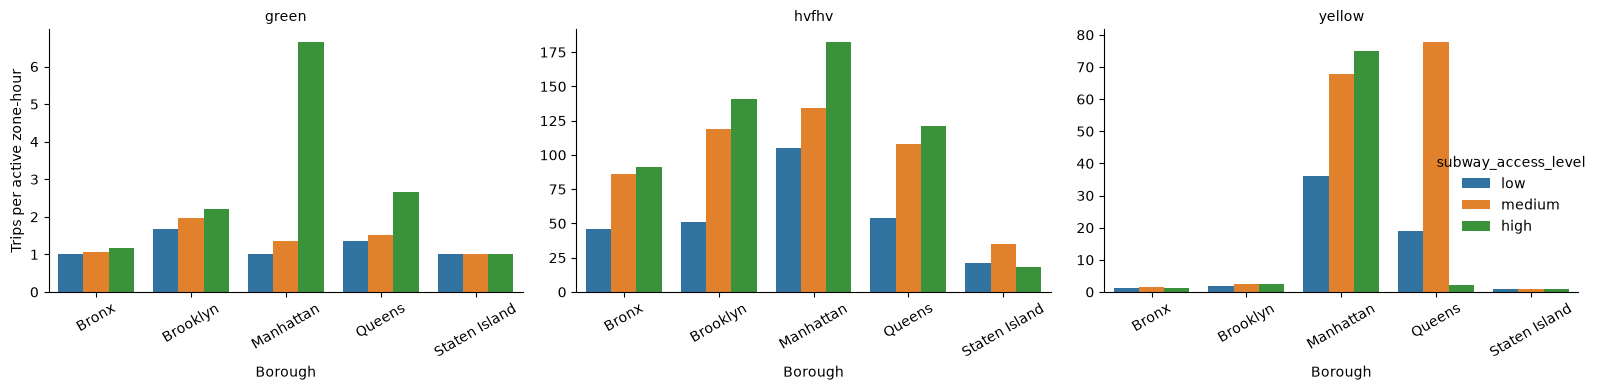

In [8]:
g = sns.catplot(
    data=borough_access_pd,
    x="borough",
    y="trips_per_active_zone_hour",
    hue="subway_access_level",
    col="service_type",
    kind="bar",
    errorbar=None,
    height=4,
    aspect=1.2,
    sharey=False,
)

g.set_axis_labels("Borough", "Trips per active zone-hour")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Earning by Borough and Accessibility

This figure is mainly supporting evidence. It shows that earning
efficiency varies much less consistently with subway accessibility than
demand does.

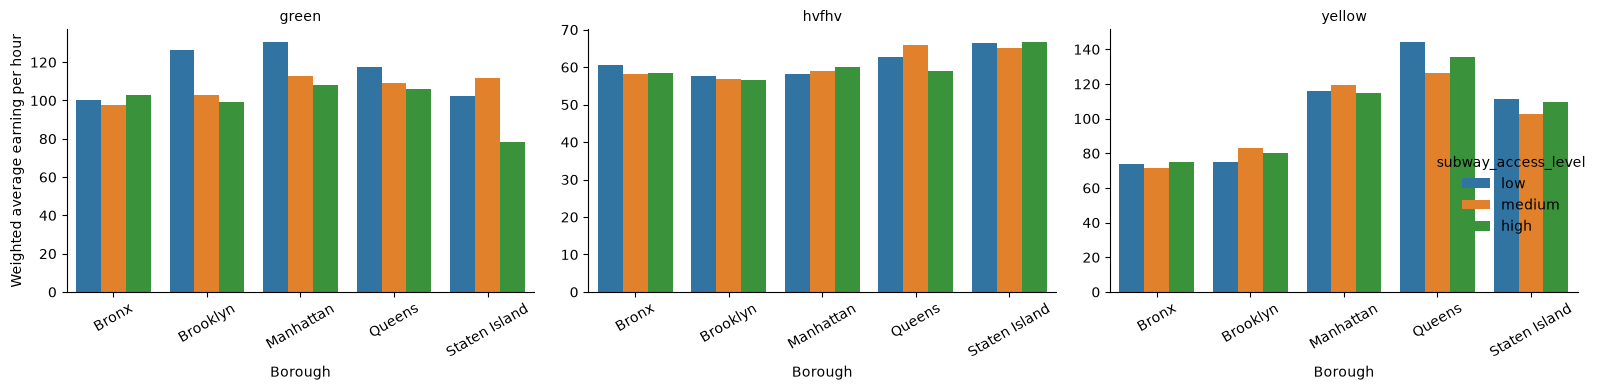

In [9]:
g = sns.catplot(
    data=borough_access_pd,
    x="borough",
    y="weighted_avg_earning_per_hour",
    hue="subway_access_level",
    col="service_type",
    kind="bar",
    errorbar=None,
    height=4,
    aspect=1.2,
    sharey=False,
)

g.set_axis_labels("Borough", "Weighted average earning per hour")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## High-Low Accessibility Gaps

Convert the borough-level plots into numeric differences. These gap
tables make it easier to describe how much higher demand is in high-access
zones relative to low-access zones.

In [10]:
access_gap = (
    borough_access_pd
    .pivot_table(
        index=["service_type", "borough"],
        columns="subway_access_level",
        values="trips_per_active_zone_hour",
        observed=True,
    )
    .reset_index()
)

access_gap["high_minus_low_demand"] = access_gap["high"] - access_gap["low"]
access_gap["high_to_low_demand_ratio"] = access_gap["high"] / access_gap["low"]

access_gap = access_gap.sort_values(
    ["service_type", "high_to_low_demand_ratio"],
    ascending=[True, False],
)

access_gap

subway_access_level,service_type,borough,low,medium,high,high_minus_low_demand,high_to_low_demand_ratio
2,green,Manhattan,1.000000,1.368997,6.658375,5.658375,6.658375
3,green,Queens,1.344780,1.504512,2.651081,1.306301,1.971386
1,green,Brooklyn,1.677419,1.975436,2.206305,0.528886,1.315297
0,green,Bronx,1.003663,1.071953,1.172982,0.169319,1.168701
4,green,Staten Island,1.000000,1.000000,1.000000,0.000000,1.000000
6,hvfhv,Brooklyn,50.856521,118.580909,140.782071,89.925551,2.768221
8,hvfhv,Queens,54.276627,107.768458,121.127308,66.850681,2.231666
5,hvfhv,Bronx,46.066032,86.107668,90.999182,44.933150,1.975407
7,hvfhv,Manhattan,105.410587,134.240118,182.524285,77.113697,1.731556
9,hvfhv,Staten Island,21.257185,34.929565,17.859102,-3.398083,0.840144


In [11]:
income_gap = (
    borough_access_pd
    .pivot_table(
        index=["service_type", "borough"],
        columns="subway_access_level",
        values="weighted_avg_earning_per_hour",
        observed=True,
    )
    .reset_index()
)

income_gap["high_minus_low_income"] = income_gap["high"] - income_gap["low"]
income_gap["high_to_low_income_ratio"] = income_gap["high"] / income_gap["low"]

income_gap = income_gap.sort_values(
    ["service_type", "high_minus_low_income"],
    ascending=[True, False],
)

income_gap

subway_access_level,service_type,borough,low,medium,high,high_minus_low_income,high_to_low_income_ratio
0,green,Bronx,100.148824,97.877370,102.731236,2.582413,1.025786
3,green,Queens,117.408048,109.214914,106.250177,-11.157871,0.904965
2,green,Manhattan,130.636405,112.932248,108.027827,-22.608579,0.826935
4,green,Staten Island,102.200235,111.783468,78.230328,-23.969907,0.765461
1,green,Brooklyn,126.354228,103.128179,99.244271,-27.109957,0.785445
7,hvfhv,Manhattan,58.277728,58.851456,59.972382,1.694654,1.029079
9,hvfhv,Staten Island,66.318761,64.979893,66.755078,0.436318,1.006579
6,hvfhv,Brooklyn,57.639258,56.928734,56.586444,-1.052815,0.981734
5,hvfhv,Bronx,60.561542,58.230080,58.440779,-2.120763,0.964982
8,hvfhv,Queens,62.781752,65.921777,58.940556,-3.841196,0.938817


In [12]:
gap_summary = (
    access_gap[
        ["service_type", "borough", "high_minus_low_demand", "high_to_low_demand_ratio"]
    ]
    .merge(
        income_gap[
            ["service_type", "borough", "high_minus_low_income", "high_to_low_income_ratio"]
        ],
        on=["service_type", "borough"],
        how="outer",
    )
)

gap_summary

subway_access_level,service_type,borough,high_minus_low_demand,high_to_low_demand_ratio,high_minus_low_income,high_to_low_income_ratio
0,green,Bronx,0.169319,1.168701,2.582413,1.025786
1,green,Brooklyn,0.528886,1.315297,-27.109957,0.785445
2,green,Manhattan,5.658375,6.658375,-22.608579,0.826935
3,green,Queens,1.306301,1.971386,-11.157871,0.904965
4,green,Staten Island,0.000000,1.000000,-23.969907,0.765461
5,hvfhv,Bronx,44.933150,1.975407,-2.120763,0.964982
6,hvfhv,Brooklyn,89.925551,2.768221,-1.052815,0.981734
7,hvfhv,Manhattan,77.113697,1.731556,1.694654,1.029079
8,hvfhv,Queens,66.850681,2.231666,-3.841196,0.938817
9,hvfhv,Staten Island,-3.398083,0.840144,0.436318,1.006579


## Hourly Demand Pattern

Examine whether the accessibility-demand relationship changes over the
day. This helps distinguish a general location effect from a pattern that
only appears during commuting or evening peak periods.

In [13]:
hourly_summary = (
    analysis_df
    .filter(F.col("borough").isin(nyc_boroughs))
    .withColumn("hour_of_day", F.hour("pickup_hour"))
    .groupBy("service_type", "subway_access_level", "hour_of_day")
    .agg(
        F.sum("trip_count").alias("total_trips"),
        F.count("*").alias("active_zone_hours"),
    )
    .withColumn(
        "trips_per_active_zone_hour",
        F.col("total_trips") / F.col("active_zone_hours"),
    )
    .orderBy("service_type", "subway_access_level", "hour_of_day")
)

hourly_pd = pd.DataFrame(
    [row.asDict() for row in hourly_summary.collect()]
)

hourly_pd["subway_access_level"] = pd.Categorical(
    hourly_pd["subway_access_level"],
    categories=["low", "medium", "high"],
    ordered=True,
)

hourly_pd.head()

,service_type,subway_access_level,hour_of_day,total_trips,active_zone_hours,trips_per_active_zone_hour
0,green,high,0,4584,2547,1.799764
1,green,high,1,3247,1972,1.646552
2,green,high,2,2240,1393,1.608040
3,green,high,3,1664,986,1.687627
4,green,high,4,1261,871,1.447761


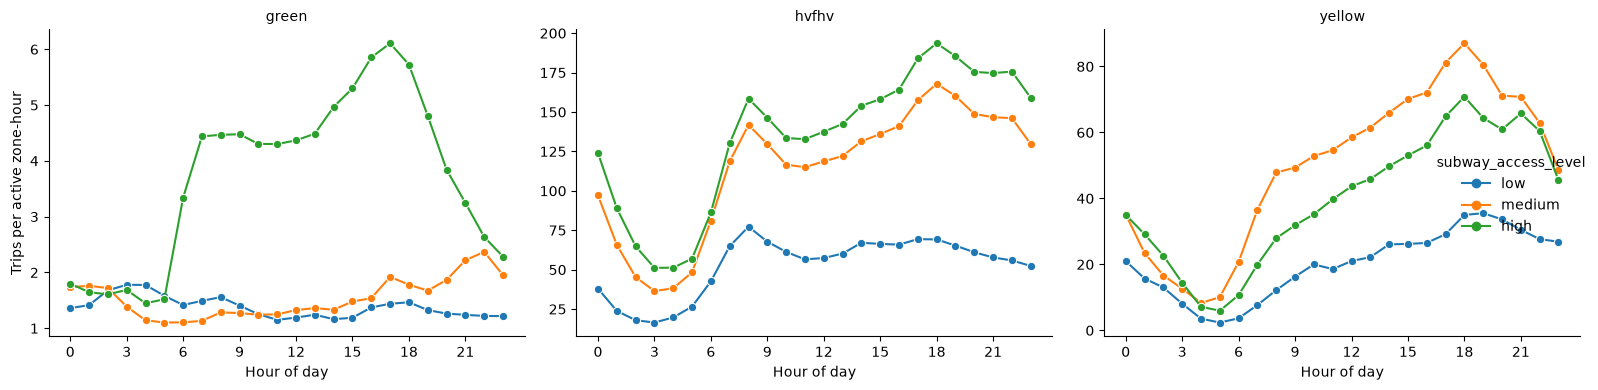

In [14]:
g = sns.relplot(
    data=hourly_pd,
    x="hour_of_day",
    y="trips_per_active_zone_hour",
    hue="subway_access_level",
    col="service_type",
    kind="line",
    marker="o",
    height=4,
    aspect=1.2,
    facet_kws={"sharey": False},
)

g.set_axis_labels("Hour of day", "Trips per active zone-hour")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

## Hourly Earning Pattern

This is a secondary diagnostic. It checks whether earnings follow the
same daily pattern as demand. In this project, the main story is that
demand and earning efficiency do not move in the same way.

In [15]:
hourly_income_summary = (
    analysis_df
    .filter(F.col("borough").isin(nyc_boroughs))
    .withColumn("hour_of_day", F.hour("pickup_hour"))
    .groupBy("service_type", "subway_access_level", "hour_of_day")
    .agg(
        F.sum("trip_count").alias("total_trips"),
        (
            F.sum(F.col("avg_earning_per_hour") * F.col("trip_count"))
            / F.sum("trip_count")
        ).alias("weighted_avg_earning_per_hour"),
    )
    .orderBy("service_type", "subway_access_level", "hour_of_day")
)

hourly_income_pd = pd.DataFrame(
    [row.asDict() for row in hourly_income_summary.collect()]
)

hourly_income_pd["subway_access_level"] = pd.Categorical(
    hourly_income_pd["subway_access_level"],
    categories=["low", "medium", "high"],
    ordered=True,
)

hourly_income_pd.head()

,service_type,subway_access_level,hour_of_day,total_trips,weighted_avg_earning_per_hour
0,green,high,0,4584,118.341243
1,green,high,1,3247,116.842928
2,green,high,2,2240,127.133116
3,green,high,3,1664,136.005789
4,green,high,4,1261,138.470062


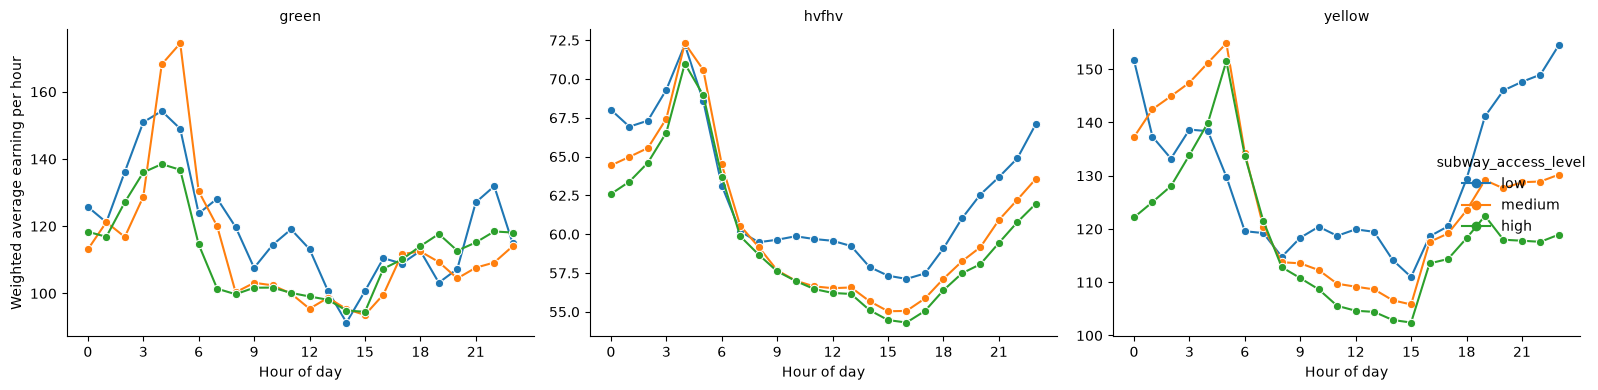

In [16]:
g = sns.relplot(
    data=hourly_income_pd,
    x="hour_of_day",
    y="weighted_avg_earning_per_hour",
    hue="subway_access_level",
    col="service_type",
    kind="line",
    marker="o",
    height=4,
    aspect=1.2,
    facet_kws={"sharey": False},
)

g.set_axis_labels("Hour of day", "Weighted average earning per hour")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

## Trip Length and Duration

Trip characteristics help explain the earning results. Lower-access
zones can have fewer trips but longer average distances and durations,
which weakens the link between accessibility and earning efficiency.

In [17]:
distance_summary = (
    analysis_df
    .filter(F.col("borough").isin(nyc_boroughs))
    .groupBy("service_type", "subway_access_level")
    .agg(
        F.sum("trip_count").alias("total_trips"),
        (
            F.sum(F.col("avg_trip_miles") * F.col("trip_count"))
            / F.sum("trip_count")
        ).alias("weighted_avg_trip_miles"),
        (
            F.sum(F.col("avg_trip_duration_minutes") * F.col("trip_count"))
            / F.sum("trip_count")
        ).alias("weighted_avg_trip_duration_minutes"),
    )
    .orderBy("service_type", "subway_access_level")
)

distance_summary_pd = pd.DataFrame(
    [row.asDict() for row in distance_summary.collect()]
)

distance_summary_pd["subway_access_level"] = pd.Categorical(
    distance_summary_pd["subway_access_level"],
    categories=["low", "medium", "high"],
    ordered=True,
)

distance_summary_pd

,service_type,subway_access_level,total_trips,weighted_avg_trip_miles,weighted_avg_trip_duration_minutes
0,green,high,288343,2.740979,14.185696
1,green,low,7121,4.649744,19.533705
2,green,medium,17134,3.743353,18.341112
3,hvfhv,high,72811592,4.196888,18.563213
4,hvfhv,low,17920151,4.989903,18.921983
5,hvfhv,medium,25084800,5.075238,20.669844
6,yellow,high,11554190,2.504308,14.742404
7,yellow,low,1547523,5.933347,22.485191
8,yellow,medium,6245663,4.203998,17.780647


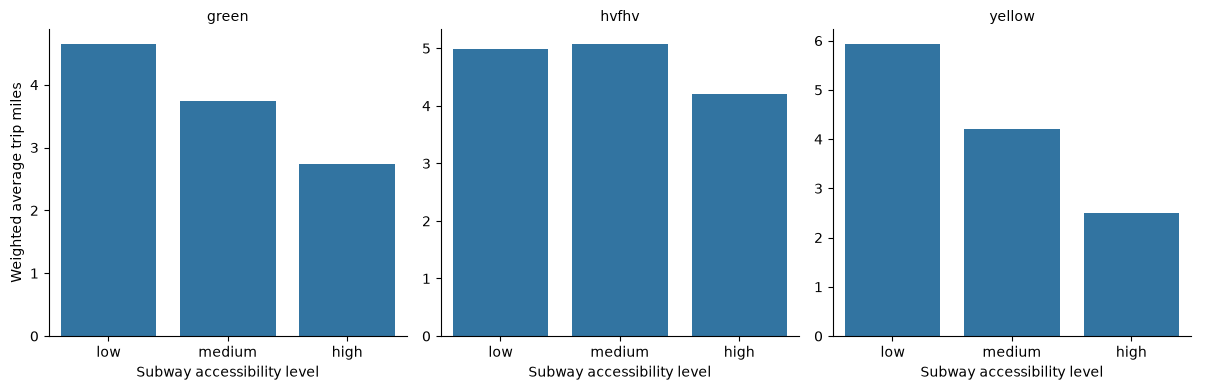

In [18]:
g = sns.catplot(
    data=distance_summary_pd,
    x="subway_access_level",
    y="weighted_avg_trip_miles",
    col="service_type",
    kind="bar",
    errorbar=None,
    height=4,
    aspect=1,
    sharey=False,
)

g.set_axis_labels("Subway accessibility level", "Weighted average trip miles")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

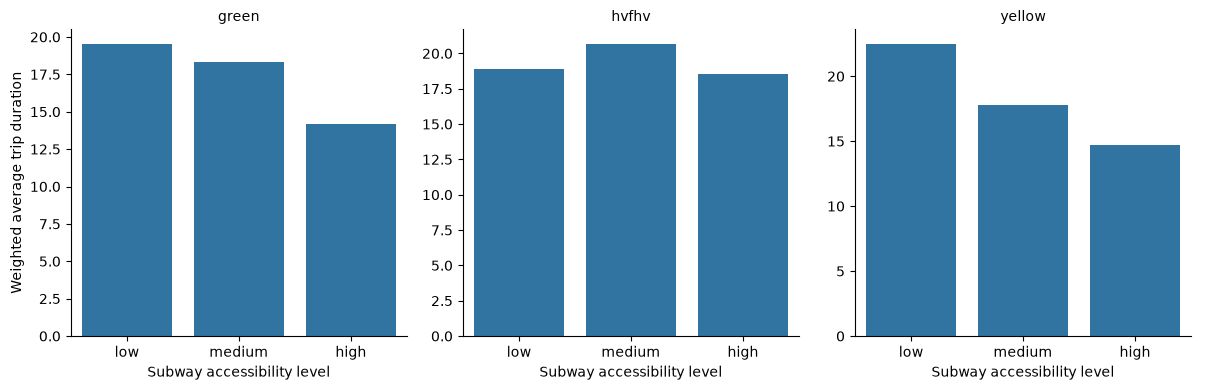

In [19]:
g = sns.catplot(
    data=distance_summary_pd,
    x="subway_access_level",
    y="weighted_avg_trip_duration_minutes",
    col="service_type",
    kind="bar",
    errorbar=None,
    height=4,
    aspect=1,
    sharey=False,
)

g.set_axis_labels("Subway accessibility level", "Weighted average trip duration")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

## Spatial Demand Hotspots

Map trip intensity at taxi-zone level. These choropleth maps show where
demand is geographically concentrated and help identify airport,
Manhattan, and Brooklyn hotspots.

In [20]:
import geopandas as gpd

TAXI_ZONES_PATH = PROJECT_ROOT / "data" / "raw" / "zones" / "taxi_zones" / "taxi_zones.shp"

taxi_zones = gpd.read_file(TAXI_ZONES_PATH)

map_summary = (
    analysis_df
    .filter(F.col("borough").isin(nyc_boroughs))
    .groupBy("service_type", "pickup_location_id")
    .agg(
        F.sum("trip_count").alias("total_trips"),
        F.count("*").alias("active_zone_hours"),
        (
            F.sum(F.col("avg_earning_per_hour") * F.col("trip_count"))
            / F.sum("trip_count")
        ).alias("weighted_avg_earning_per_hour"),
    )
    .withColumn(
        "trips_per_active_zone_hour",
        F.col("total_trips") / F.col("active_zone_hours"),
    )
)

map_summary_pd = pd.DataFrame(
    [row.asDict() for row in map_summary.collect()]
)

map_gdf = taxi_zones.merge(
    map_summary_pd,
    left_on="LocationID",
    right_on="pickup_location_id",
    how="left",
)

### HVFHV Spatial Heatmap

This is the most useful map for the report because HVFHV has the largest
volume and the broadest spatial coverage across NYC.

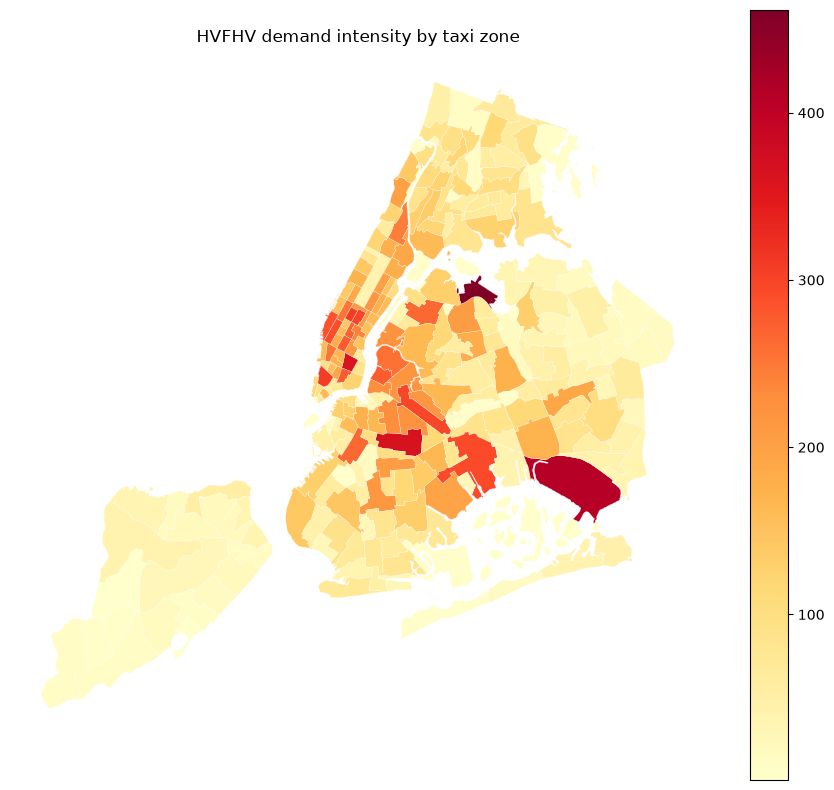

In [21]:
hvfhv_map = map_gdf[map_gdf["service_type"] == "hvfhv"]

fig, ax = plt.subplots(figsize=(9, 8))

hvfhv_map.plot(
    column="trips_per_active_zone_hour",
    cmap="YlOrRd",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"},
)

ax.set_title("HVFHV demand intensity by taxi zone")
ax.axis("off")

plt.tight_layout()
plt.show()

### Service-Level Map Comparison

This comparison is exploratory. The three maps use different colour
scales, so they should not be used to compare absolute demand levels
across services by colour intensity alone.

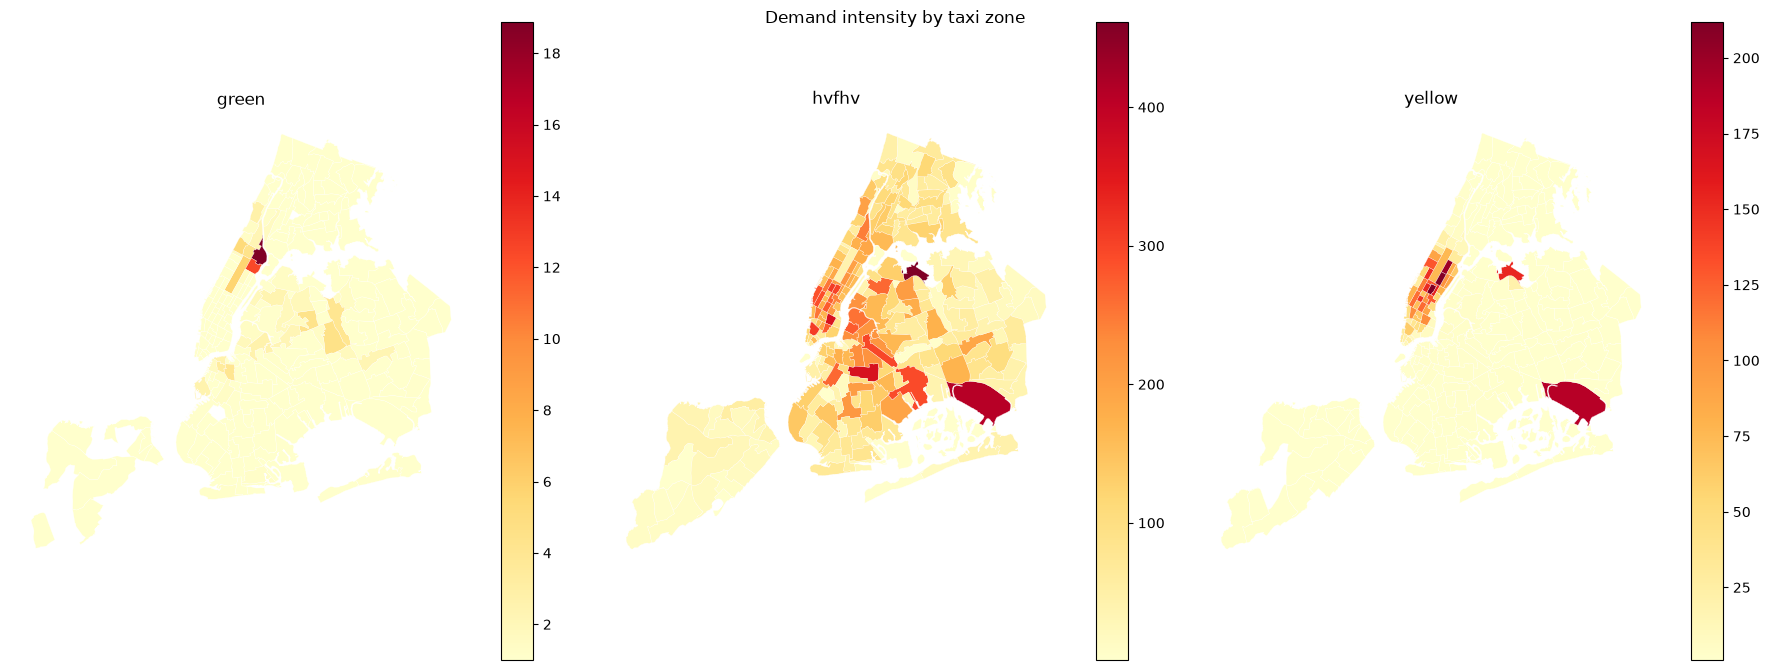

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, service in zip(axes, ["green", "hvfhv", "yellow"]):
    service_map = map_gdf[map_gdf["service_type"] == service]
    
    service_map.plot(
        column="trips_per_active_zone_hour",
        cmap="YlOrRd",
        linewidth=0.2,
        edgecolor="white",
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey"},
    )
    
    ax.set_title(service)
    ax.axis("off")

plt.suptitle("Demand intensity by taxi zone", y=0.95)
plt.tight_layout()
plt.show()

### Top Demand Zones

List the highest-demand taxi zones for each service. This helps interpret
the maps and confirms the importance of airports, Manhattan activity
centres, and selected Brooklyn neighbourhoods.

In [23]:
top_demand_zones = (
    map_summary_pd
    .merge(
        taxi_zones[["LocationID", "borough", "zone"]],
        left_on="pickup_location_id",
        right_on="LocationID",
        how="left",
    )
    .sort_values(["service_type", "trips_per_active_zone_hour"], ascending=[True, False])
    .groupby("service_type")
    .head(10)
    [
        [
            "service_type",
            "borough",
            "zone",
            "total_trips",
            "trips_per_active_zone_hour",
            "weighted_avg_earning_per_hour",
        ]
    ]
)

top_demand_zones

,service_type,borough,zone,total_trips,trips_per_active_zone_hour,weighted_avg_earning_per_hour
532,green,Manhattan,East Harlem North,72604,18.872888,99.973341
692,green,Manhattan,East Harlem South,45891,12.392925,115.843565
660,green,Manhattan,Central Park,15942,5.742795,120.102605
581,green,Manhattan,Morningside Heights,17012,5.293093,110.763139
546,green,Queens,Forest Hills,16141,4.518757,98.191917
682,green,Manhattan,Central Harlem,14564,4.413333,105.410054
733,green,Queens,Elmhurst,15084,4.382336,108.071366
591,green,Queens,Flushing Meadows-Corona Park,1200,4.026846,159.136119
711,green,Brooklyn,Fort Greene,10548,4.003036,87.462532
712,green,Brooklyn,Downtown Brooklyn/MetroTech,9596,3.384832,92.810119


## Airport Sensitivity Check

Airport zones are strong location outliers. This section tests whether
the subway accessibility pattern remains after excluding JFK, LaGuardia,
and Newark airport zones.

### Airport and Non-Airport Comparison

Quantify how different airport zones are from other NYC taxi zones. This
justifies treating airports as a sensitivity check rather than letting
them dominate the main interpretation.

In [24]:
airport_zone_names = ["JFK Airport", "LaGuardia Airport", "Newark Airport"]

airport_effect_summary = (
    analysis_df
    .filter(F.col("borough").isin(nyc_boroughs))
    .withColumn("is_airport_zone", F.col("zone").isin(*airport_zone_names))
    .groupBy("service_type", "is_airport_zone")
    .agg(
        F.sum("trip_count").alias("total_trips"),
        F.count("*").alias("active_zone_hours"),
        F.countDistinct("pickup_location_id").alias("pickup_zones"),
        (
            F.sum(F.col("avg_earning_per_hour") * F.col("trip_count"))
            / F.sum("trip_count")
        ).alias("weighted_avg_earning_per_hour"),
    )
    .withColumn(
        "trips_per_active_zone_hour",
        F.col("total_trips") / F.col("active_zone_hours"),
    )
    .orderBy("service_type", "is_airport_zone")
)

airport_effect_pd = pd.DataFrame(
    [row.asDict() for row in airport_effect_summary.collect()]
)

airport_effect_pd

,service_type,is_airport_zone,total_trips,active_zone_hours,pickup_zones,weighted_avg_earning_per_hour,trips_per_active_zone_hour
0,green,False,312480,85464,236,106.813156,3.656276
1,green,True,118,115,2,188.660131,1.026087
2,hvfhv,False,112026773,1088628,258,58.833889,102.906386
3,hvfhv,True,3789770,8722,2,68.390315,434.506994
4,yellow,False,17917347,472098,255,115.725825,37.952601
5,yellow,True,1430029,8379,2,135.030612,170.668218


### Accessibility Summary Without Airports

Recalculate demand and earning measures after excluding airport zones.
This is the cleaner version of the accessibility comparison for the final
report.

In [25]:
analysis_no_airport = (
    analysis_df
    .filter(F.col("borough").isin(nyc_boroughs))
    .filter(~F.col("zone").isin(*airport_zone_names))
)

no_airport_access_summary = (
    analysis_no_airport
    .groupBy("service_type", "subway_access_level")
    .agg(
        F.sum("trip_count").alias("total_trips"),
        F.count("*").alias("active_zone_hours"),
        F.countDistinct("pickup_location_id").alias("pickup_zones"),
        (
            F.sum(F.col("avg_earning_per_hour") * F.col("trip_count"))
            / F.sum("trip_count")
        ).alias("weighted_avg_earning_per_hour"),
    )
    .withColumn(
        "trips_per_active_zone_hour",
        F.col("total_trips") / F.col("active_zone_hours"),
    )
    .orderBy("service_type", "subway_access_level")
)

no_airport_access_pd = pd.DataFrame(
    [row.asDict() for row in no_airport_access_summary.collect()]
)

no_airport_access_pd["subway_access_level"] = pd.Categorical(
    no_airport_access_pd["subway_access_level"],
    categories=access_order,
    ordered=True,
)

no_airport_access_pd = no_airport_access_pd.sort_values(
    ["service_type", "subway_access_level"]
)

no_airport_access_pd

,service_type,subway_access_level,total_trips,active_zone_hours,pickup_zones,weighted_avg_earning_per_hour,trips_per_active_zone_hour
1,green,low,7059,5186,70,117.192193,1.361165
2,green,medium,17078,10560,47,106.607031,1.617235
0,green,high,288343,69718,119,106.571272,4.135847
4,hvfhv,low,15910530,333444,84,60.468968,47.715748
5,hvfhv,medium,23304651,214329,50,58.436836,108.733074
3,hvfhv,high,72811592,540855,124,58.603681,134.623128
7,yellow,low,936916,73632,81,116.901999,12.724305
8,yellow,medium,5426241,115410,50,118.775290,47.017078
6,yellow,high,11554190,283056,124,114.198318,40.819449


### High-Low Gap Without Airports

Measure whether high-access zones still have higher demand than low-access
zones once airports are removed.

In [26]:
no_airport_demand_gap = (
    no_airport_access_pd
    .pivot_table(
        index="service_type",
        columns="subway_access_level",
        values="trips_per_active_zone_hour",
        observed=True,
    )
    .reset_index()
)

no_airport_demand_gap["high_minus_low_demand"] = (
    no_airport_demand_gap["high"] - no_airport_demand_gap["low"]
)
no_airport_demand_gap["high_to_low_demand_ratio"] = (
    no_airport_demand_gap["high"] / no_airport_demand_gap["low"]
)

no_airport_income_gap = (
    no_airport_access_pd
    .pivot_table(
        index="service_type",
        columns="subway_access_level",
        values="weighted_avg_earning_per_hour",
        observed=True,
    )
    .reset_index()
)

no_airport_income_gap["high_minus_low_income"] = (
    no_airport_income_gap["high"] - no_airport_income_gap["low"]
)
no_airport_income_gap["high_to_low_income_ratio"] = (
    no_airport_income_gap["high"] / no_airport_income_gap["low"]
)

no_airport_gap_summary = (
    no_airport_demand_gap[
        [
            "service_type",
            "high_minus_low_demand",
            "high_to_low_demand_ratio",
        ]
    ]
    .merge(
        no_airport_income_gap[
            [
                "service_type",
                "high_minus_low_income",
                "high_to_low_income_ratio",
            ]
        ],
        on="service_type",
        how="outer",
    )
)

no_airport_gap_summary

subway_access_level,service_type,high_minus_low_demand,high_to_low_demand_ratio,high_minus_low_income,high_to_low_income_ratio
0,green,2.774683,3.038462,-10.620921,0.909372
1,hvfhv,86.907380,2.821356,-1.865287,0.969153
2,yellow,28.095145,3.207991,-2.703681,0.976872


### Demand Without Airports

This is a core report figure. It shows that high-access zones still have
substantially higher demand intensity even after removing airport zones.

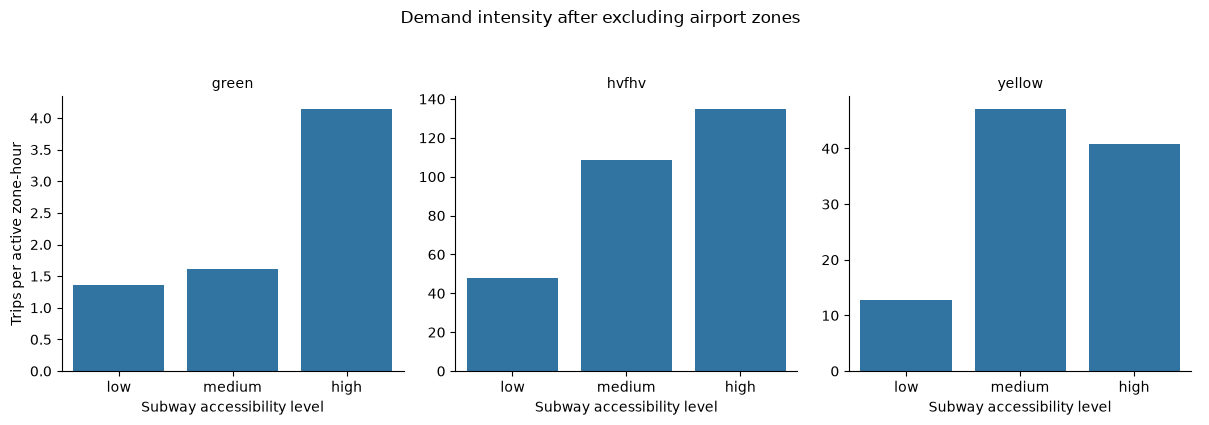

In [27]:
g = sns.catplot(
    data=no_airport_access_pd,
    x="subway_access_level",
    y="trips_per_active_zone_hour",
    col="service_type",
    kind="bar",
    order=access_order,
    errorbar=None,
    height=4,
    aspect=1,
    sharey=False,
)

g.set_axis_labels("Subway accessibility level", "Trips per active zone-hour")
g.set_titles("{col_name}")

plt.suptitle("Demand intensity after excluding airport zones", y=1.05)
plt.tight_layout()
plt.show()

### Earning Without Airports

This supporting plot shows that the accessibility-demand pattern does not
translate into a similarly strong earning-efficiency pattern.

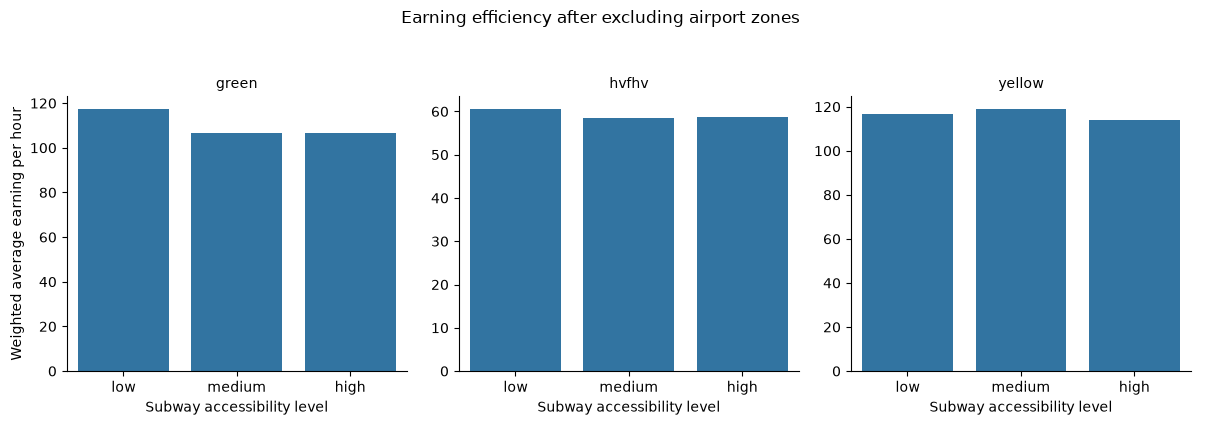

In [28]:
g = sns.catplot(
    data=no_airport_access_pd,
    x="subway_access_level",
    y="weighted_avg_earning_per_hour",
    col="service_type",
    kind="bar",
    order=access_order,
    errorbar=None,
    height=4,
    aspect=1,
    sharey=False,
)

g.set_axis_labels("Subway accessibility level", "Weighted average earning per hour")
g.set_titles("{col_name}")

plt.suptitle("Earning efficiency after excluding airport zones", y=1.05)
plt.tight_layout()
plt.show()